# Tidal-Spin Calculations under a Representative EoS

## Representative EoS: POLYn1

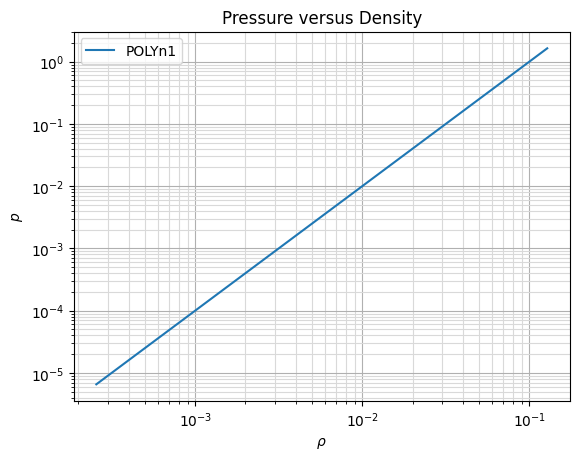

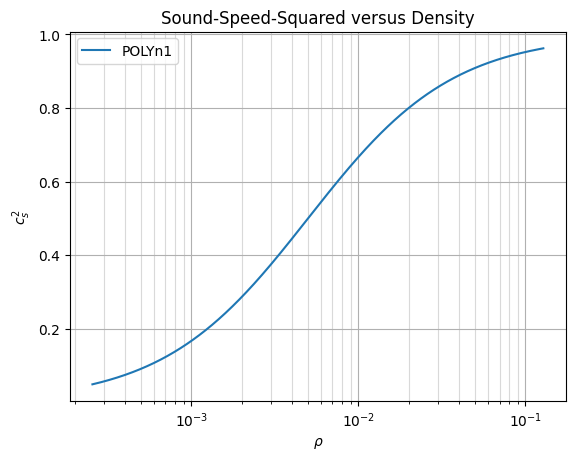

In [1]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd
import itertools


#CoRe import

polyn1 = np.loadtxt('g2k100_mvsr.dat')
pfD = pd.DataFrame(polyn1, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
dataM_POLYn1 = pfD["M"].to_numpy()
dataR_POLYn1 = pfD["R"].to_numpy()
dataL_POLYn1 = pfD["Lambda"].to_numpy()

#MacKay Solver import

POLYn1 = np.loadtxt('POLYn1_MacKay.dat')
PfD = pd.DataFrame(POLYn1, columns=["rho_central", "M", "R"])
M_POLY = PfD["M"].to_numpy()
R_POLY = PfD["R"].to_numpy()
r_POLY = PfD["rho_central"].to_numpy()

#EoS cell

def eos_p_POLY(rho):
    return 100 * rho**2

def eos_rho_POLY(p):
    rho_rest = (p / 100)**(1/2)
    return rho_rest + p/(2-1)

def eos_cs2_POLY(rho):
    dpdrho = 2 * 100 * rho**(2 - 1)
    dedrho = 1 + dpdrho/(2 - 1)
    return dpdrho / dedrho

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 100 * rho_base
rho_c_space = np.logspace(np.log10(rho_min),
                          np.log10(rho_max), 1000)

# Plot the EOS
f1=plt.figure()
plt.loglog(rho_c_space, eos_p_POLY(rho_c_space), label="POLYn1")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
plt.semilogx(rho_c_space, eos_cs2_POLY(rho_c_space), label="POLYn1")
plt.title("Sound-Speed-Squared versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$c_s^2$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#f2.savefig("all_eos_cs2vrho.png", bbox_inches='tight', dpi=300)

## TOV(+tidal+spin) ODEs and Solver

In [2]:
## The TOV Solver (with rotations + Tidal ODE) ##
#-----------------------------------#
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
from scipy.integrate import solve_ivp
import pandas as pd

#TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, rho):
    if r <= 0:
        return 0
    return -(rho + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
    
def dm_dr(r, p, m, rho):
    return 4 * pi * r**2 * rho

#y2
def dy2_dr(r, y2, p, m, rho, cs2):
    if r<=1e-6:
        return 2
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-2*(2+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y2**2/r + y2*F + r*G)

#H2
H20 = 1e-10
def dH2_dr(r, H2, y2):
    if r<=1e-6:
        return H20
    return (y2*H2)/r

#Hartle-Thorne equation
Om=1e-3 #test value

def dv_dr(r, p, m, v, rho):
    if r <= 1e-6:
        return 0
    B = (4*pi*(p+rho))/(1-2*m/r)
    return -3*v/r - v**2/r + r*B*(v+4)
    
def dw_dr(r, v, w):
    if r<=1e-6:
        return Om
    return v*w/r

#==================
# Octopole numbers
#==================
#y3
def dy3_dr(r, y3, p, m, rho, cs2):
    if r<=1e-6:
        return 3
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-3*(3+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y3**2/r + y3*F + r*G)
    
#y*3
def dys3_dr(r, ys3, p, m, rho):
    if r<=1e-6:
        return 3+1
    A = 1/r + (4*pi*r**2*(p + rho))/(r - 2*m)
    B = (3*(3+1)/r - 4*m/r**2 + 8*pi*r*(p+rho))/(r - 2*m)
    return -(ys3**2/r - ys3*A - r*B)

def tov_equations(r, state, eos_rho, eos_cs2):
    p, m, y2, H2, v, w, y3, ys3 = state
    rho = eos_rho(p)
    cs2 = eos_cs2(rho)
    return [
        dp_dr(r, p, m, rho),
        dm_dr(r, p, m, rho),
        dy2_dr(r, y2, p, m, rho, cs2),
        dH2_dr(r, H2, y2),
        dv_dr(r, p, m, v, rho),
        dw_dr(r, v, w),
        dy3_dr(r, y3, p, m, rho, cs2),
        dys3_dr(r, ys3, p, m, rho)
    ]


In [3]:

#=====================
# The Big Source Term
#=====================


def S_star_plus(r, p, m, rho, w, eos_cs2, Om, y2, H2):
    cs2 = eos_cs2
    y = y2
    e = w/Om
    
    T1 = r*((p+rho)/cs2)*(2-e)
    
    T2 = r**2/(2*(r-2*m))*(
        m/r *(-8*rho*(5-4*e)-e/(np.pi*r**2)
             +p*(32*(4*np.pi*r**2*rho-1)+88*e)+32*np.pi*r**2*(3*p**2+rho**2))
        +4*((2*rho+p)*(1+(4*np.pi*r**2*p)**2-4*np.pi*r**2*p)
            +4*np.pi*r**2*(5*p**2-rho**2)+(4*np.pi*r**2)**2*p**3-2*p
        +(1-e)*((2*p*(3-10*np.pi*r**2*p)+4*rho)-1/(2*np.pi*r**2))+1/(2*np.pi*r**2))
        -m**2/r**2 * (e/(np.pi*r**2)+2*(p+rho)))
   
    T3 = -e/(2*np.pi)+m/(4*np.pi*r)*(
        9*e+8*np.pi*r**2*(p+rho)) +r**2*p*(
        5*e+8*np.pi*r**2*(p+rho))

    S = -(4*np.pi/((35)**(1/2))*(r**2/(r-2*m)))*H2*Om*(T1 + T2 + y*T3/r)
    return S


def dy32_dr(r, u, p, m, rho, w, eos_cs2, Om, y2, H2):
    h, y = u

    Psi = (4*pi*r**2*(p + rho))/(r - 2*m)
    Z = (12 - 4*m/r + 8*pi*r**2*(p+rho)) / (r*(r - 2*m))
    S = S_star_plus(r, p, m, rho, w, eos_cs2, Om, y2, H2)

    if r <= 1e-6:
        return [H20, 4.0]

    dhdr = (y/r) * h
    dydr = (Psi*y + r*Z + (y - y**2)/r + (S*r)/h)

    return [dhdr, dydr]

def make_dy32(eos_rho, eos_cs2, w_array, Om, y2_array, H2_array, r_array):
    def f(r, u, p, m, w, Om):
        rho = eos_rho(p)
        cs2 = eos_cs2(rho)
        
        w = np.interp(r, r_array, w_array)
        y2 = np.interp(r, r_array, y2_array)
        H2 = np.interp(r, r_array, H2_array)

        return dy32_dr(r, u, p, m, rho, w, cs2, Om, y2, H2)
    return f


In [4]:
#TOV integrator, from r=0 outwards, until p=0 (we yield r=R)

def solve_tov_equations(p_central, eos_rho, eos_cs2, step):
    r_initial = 1e-6
    state_initial = [ p_central, 0., 2, H20, 0., Om, 3, 4 ] #p, m, y2, H2, v, w, y3, ys3
    
    #integrator = ode(tov_equations).set_integrator('LSODA', rtol=1e-8, atol=1e-10, nsteps=10000, max_step=1e4)
    integrator = ode(tov_equations).set_integrator('dopri5')
    integrator.set_initial_value(state_initial, r_initial)
    integrator.set_f_params(eos_rho, eos_cs2)
    
    r_path = []
    p_path = []
    m_path = []
    y2_path = []
    H2_path = []
    v_path = []
    w_path = []
    y3_path = []
    ys3_path = []

    while integrator.successful():
        integrator.integrate(integrator.t + step)

        r = integrator.t
        p, m, y2, H2, v, w, y3, ys3 = integrator.y 

        r_path.append(r)
        p_path.append(p)
        m_path.append(m)
        y2_path.append(y2)
        H2_path.append(H2)
        v_path.append(v)
        w_path.append(w)
        y3_path.append(y3)
        ys3_path.append(ys3)

        if p < 0:
            break
    return (np.array(r_path),
            np.array(p_path),
            np.array(m_path),
            np.array(y2_path),
            np.array(H2_path),
            np.array(v_path),
            np.array(w_path),
            np.array(y3_path),
            np.array(ys3_path)
        )

#Auxiliary RK4 for tidal-interference Love
def integrate_auxiliary_2(r, p, m, w, y0, deriv):

    y = np.zeros((len(r), 2))
    y[0] = y0

    for i in range(1, len(r)):

        dr = r[i] - r[i-1]

        r0 = r[i-1]
        p0 = p[i-1]
        m0 = m[i-1]
        w0 = w[i-1]
        O = Om
        y_prev = y[i-1]

        k1 = np.array(deriv(r0, y_prev, p0, m0, w0, O))
        k2 = np.array(deriv(r0 + dr/2, y_prev + dr*k1/2, p0, m0, w0, O))
        k3 = np.array(deriv(r0 + dr/2, y_prev + dr*k2/2, p0, m0, w0, O))
        k4 = np.array(deriv(r0 + dr, y_prev + dr*k3, p0, m0, w0, O))

        y[i] = y_prev + dr*(k1 + 2*k2 + 2*k3 + k4)/6

    return y

### One sample NS

/tmp/ipykernel_15014/3613917470.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / 100)**(1/2)


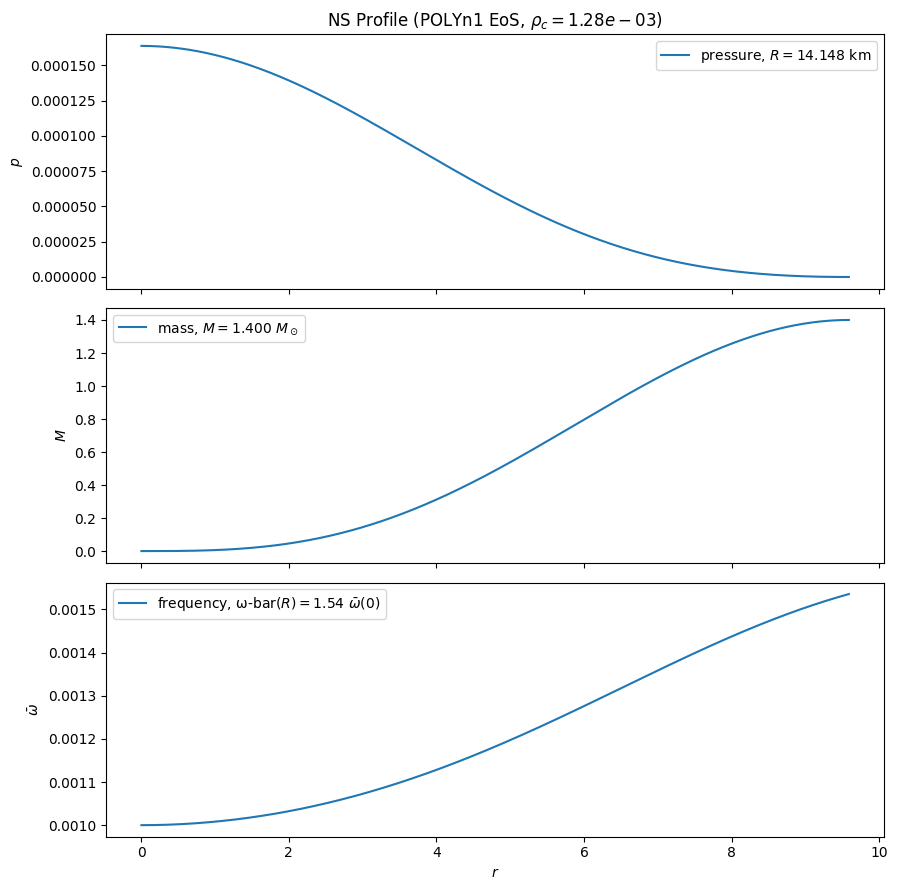

In [6]:
# Omega profile of one sample star

rho_c = 1.28e-3 #3.5 units of nuclear saturation 
p_central1 = eos_p_POLY(rho_c)

r, p, m, y2, H2, v, w, y3, ys3 = solve_tov_equations(                          
    p_central=p_central1,
    eos_rho=eos_rho_POLY,
    eos_cs2=eos_cs2_POLY,
    step=0.005
)

dy32 = make_dy32(eos_rho_POLY, eos_cs2_POLY, w, Om, y2, H2, r)
y32_path = integrate_auxiliary_2(r, p, m, w, [H20, 4.0], dy32)
Y32 = y32_path[-1,1]
        
R = r[-1]
M = m[-1]
W = w[-1]
h2 = H2[-1]

   #Plotting
fig, axes = plt.subplots(figsize=(9, 9), nrows=3, sharex=True)

axes[0].plot(r, p, label=r"pressure, $R = {:.3f}$".format(R*1.476)+" km")
axes[1].plot(r, m, label=r"mass, $M = {:.3f}$".format(M)+" $M_\odot$")
axes[2].plot(r, w, label=r"frequency, ω-bar$(R) = {:.2f}$".format(W/Om)+r" $\bar{\omega}(0)$")

axes[0].set_title(r"NS Profile (POLYn1 EoS, $\rho_c = {:.2e}$".format(rho_c)+")")
axes[0].set_ylabel(r"$p$")
axes[0].legend()

axes[1].set_ylabel(r"$M$")
axes[1].legend()

axes[2].set_ylabel(r"$\bar{\omega}$")
axes[2].set_xlabel(r"$r$")
axes[2].legend()

fig.tight_layout()
plt.show()

#fig.savefig("NS_POLYn1_profs_with_spin.png", bbox_inches='tight', dpi=300)

## MRL data

In [5]:
#By varying the central density, we obtain possible values for mass, radius, and log ratio: 

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 6 * rho_base

def POLYn1_eos_MRLY(eos_p,
                   eos_rho,
                   eos_cs2,
                   rho_central_start=rho_min,
                   rho_central_log_step=0.05,
                   rho_central_stop=rho_max,
                   stop_at_maximum_mass=False):

    data = pd.DataFrame(
        columns=['rho_central', 'M', 'R', 'k2', 'Lambda2', 'h2','W', 'k3', 'ks3', 'Y2', 'Ys3', 'Y32', 'P']).set_index('rho_central')
    rho_central = rho_central_start
    while rho_central < rho_central_stop:
        # Central pressure
        p_central = eos_p(rho_central)
        # Solve TOV + tidal
        r, p, m, y2, H2, v, w, y3, ys3 = solve_tov_equations(
            p_central=p_central,
            eos_rho=eos_rho,
            eos_cs2=eos_cs2,
            step=0.001)

        dy32 = make_dy32(eos_rho, eos_cs2, w, Om, y2, H2, r)
        y32_path = integrate_auxiliary_2(r, p, m, w, [H20, 4.0], dy32)
        Y32 = y32_path[-1,1]

        R = r[-1]
        M = m[-1]
        Y2 = y2[-1]
        Y3 = y3[-1]
        Ys3 = ys3[-1]
        W = w[-1]
        h2 = H2[-1]

        C = M / R

        if C < 1e-10:
            k2, P, k3, ks3 = np.nan
        else:
            log = np.log(1 - 2*C)

            k2=((8 * C**5 / 5) * (1 - 2*C)**2 * (2 + 2*C*(Y2 - 1) - Y2))/((2*C*(6 - 3*Y2 + 3*C*(5*Y2 - 8)) +
        4*C**3*(13 - 11*Y2 + C*(3*Y2 - 2) + 2*C**2*(1 + Y2)) +
        3*(1 - 2*C)**2 * (2 - Y2 + 2*C*(Y2 - 1)) * log))

            k3=((8 * C**7 / 7) * (1 - 2*C)**2 * (2*C**2*(Y3-1)-3*C*(Y3-2)+Y3-3))/(2*C*(4*C**5*(Y3+1) + 
        2*C**4*(9*Y3-2)+20*C**3*(9-7*Y3)+5*C**2*(37*Y3-72)+45*C*(5-2*Y3)+15*(Y3-3))
        + 15*(1-2*C)**2*(-3+Y3+C*(6+2*C*(Y3-1)-3*Y3))* log)

            ks3=((3 * C**7) * (3*(Ys3-4)-10*C*(Ys3-3) + C**2*(Ys3 - 2)))/(98*C*(45*(Ys3-4) + 
        30*C**2*(Ys3-1)+10*C**3*Ys3+4*C**4*(Ys3+1)-15*C*(7*Ys3-18)) 
        + 735*(3*(Ys3-4)-10*C*(Ys3-3)+8*C**2*(Ys3-2)) * log)

            arccoth = log/2

            P = -((3*(5/7)**(1/2)*(4*C*(585*(-4+Y32)+C*(8190-2535*Y32+2*C*(195*(-19+8*Y32)
                                                                           +C*(65*(6-5*Y32)+2*C*(13-142*Y32
                                                                                                 +2*C*(23+68*Y32+18*C*(2+Y32)))))))
                                   -18*(-1+2*C)*(405*(-4+Y32)+2*C*(2025-1080*C+32*C**4+(-5+4*C)*(135+8*C**3)*Y32))*arccoth
                      +825*(-1+2*C)*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log))/(
                1792*(-1+2*C)*(30*C**2*(18-7*Y32)+90*C*(-4+Y32)+60*C**3*(-1+Y32)+20*C**4*Y32+8*C**5*(1+Y32)
                               +15*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log)))
            
           
        if np.isfinite(k2) and k2 > 0:
                Lambda2 = (2/3) * k2 / C**5
        else:
                Lambda2 = np.nan
                
        
        # Optional stopping at maximum mass
        if stop_at_maximum_mass and len(data) > 0:
            if M < data['M'].iat[-1]:
                break

        data.loc[rho_central] = [M, R, k2, Lambda2, h2, W, k3, ks3, Y2, Ys3, Y32, P]

        # Log stepping
        rho_central += rho_central * rho_central_log_step
    return data

POLYn1_data = POLYn1_eos_MRLY(eos_p=eos_p_POLY,
                              eos_rho=eos_rho_POLY,
                              eos_cs2=eos_cs2_POLY,
                              );


/tmp/ipykernel_7372/3613917470.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / 100)**(1/2)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7372/3613917470.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / 100)**(1/2)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7372/3613917470.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / 100)**(1/2)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7372/3613917470.py:34: RuntimeW

In [6]:
#extract the computations

rho_vals = POLYn1_data.index.values
M_vals = POLYn1_data['M'].values
R_vals = POLYn1_data['R'].values
k2_vals = POLYn1_data['k2'].values
k3_vals = POLYn1_data['k3'].values
ks3_vals = POLYn1_data['ks3'].values
Lambda_vals = POLYn1_data['Lambda2'].values
Y2_vals = POLYn1_data['Y2'].values
Ys3_vals = POLYn1_data['Ys3'].values
Y32_vals = POLYn1_data['Y32'].values
P_vals = POLYn1_data['P'].values
W_vals = POLYn1_data['W'].values
H2_vals = POLYn1_data['h2'].values


In [8]:
#To see how much different are the sourceless solutions y^*_3 are to the sourced solutions y_{32}

print(np.abs(Y32_vals-Ys3_vals))
print()
print(np.min(np.abs(Y32_vals-Ys3_vals)))
print(np.max(np.abs(Y32_vals-Ys3_vals)))

[1.09969132e-04 1.08724795e-04 1.07433725e-04 1.06094102e-04
 1.04709744e-04 1.03279294e-04 1.01798091e-04 1.00268107e-04
 9.86846221e-05 9.70573163e-05 9.53766580e-05 9.36435636e-05
 9.18570992e-05 9.00276951e-05 8.81389601e-05 8.62064766e-05
 8.42162180e-05 8.21808536e-05 8.00968013e-05 7.79585484e-05
 7.57758930e-05 7.35503257e-05 7.12730339e-05 6.89513188e-05
 6.65958663e-05 6.41939687e-05 6.17493929e-05 5.92678131e-05
 5.67556258e-05 5.42172209e-05 5.16481876e-05 4.90411890e-05
 4.64121695e-05 4.37746333e-05 4.11003496e-05 3.84275127e-05
 3.57293249e-05 3.30246860e-05 3.03078442e-05 2.76044585e-05
 2.48953795e-05 2.21788564e-05 1.94725187e-05 1.67802240e-05
 1.40943178e-05 1.14495745e-05 8.80084692e-06 6.19756763e-06
 3.61626008e-06 1.06672810e-06 1.45355846e-06 3.93798317e-06
 6.37470832e-06 8.76095558e-06 1.11155739e-05 1.33971649e-05
 1.56095596e-05 1.77649755e-05 1.98724825e-05 2.18670026e-05
 2.38381982e-05 2.56782833e-05 2.74719718e-05 2.91962892e-05
 3.07833330e-05 3.230307

In [15]:
#To see how large the p^*_{32} polynomial is computed to be.

print(P_vals)
print()
print(np.min(P_vals))
print(np.max(P_vals))

[0.15106661 0.15086796 0.15066204 0.15044874 0.1502279  0.14999941
 0.14976315 0.14951903 0.14926696 0.14900688 0.14873872 0.14846247
 0.14817809 0.14788561 0.14758504 0.14727646 0.14695992 0.14663555
 0.14630347 0.14596386 0.1456169  0.14526283 0.14490191 0.14453442
 0.14416069 0.14378108 0.14339599 0.14300584 0.14261108 0.14221221
 0.14180975 0.14140424 0.14099627 0.14058644 0.14017538 0.13976373
 0.13935217 0.13894139 0.13853206 0.13812492 0.13772067 0.13732007
 0.13692372 0.13653247 0.13614697 0.13576796 0.13539606 0.13503204
 0.13467644 0.13432999 0.13399327 0.13366687 0.13335134 0.13304725
 0.13275502 0.13247519 0.13220818 0.1319544  0.1317142  0.13148794
 0.13127592 0.13107843 0.13089569 0.13072792 0.1305753  0.13043798
 0.13031608 0.13020969 0.13011885 0.13004361]

0.1300436093856292
0.1510666086640476


## Pani plots

In https://arxiv.org/abs/1509.02171, their Fig 2 shows a plot of the ratio
\begin{equation}
\mathrm{Pani~ notation:}\quad\frac{\delta\tilde{\lambda}^{(23)}_E}{|\tilde{\lambda}^{(2)}_E|}
\end{equation}
across various choices of EoS (including simple polytrope) over the range in compactness $C\in[0.05,\,0.3]$. Eq. (42) in Pani II shows a representative expression for $\delta\tilde{\lambda}_{(32)}$, independent of EoS:  
\begin{equation}
\delta\tilde{\lambda}^{(32)}_E=\chi\frac{A_1+A_2\log(1-2C)}{A_3+A_4\log(1-2C)+A_5\log(1-2C)^2},
\end{equation}
where $A_i$ are cumbersome polynomials dependent on $C$ and surface-level logarithmic ratios $y_l^{(*)}(R)$. We recognize that Eq. (42) -- denoting a dimensonless quantity $\delta\lambda_{(32)}/(\chi M^6)$ -- is scaled by $\chi$; there's reason to suggest this may be a typo.

Similar to the representative expression for $\delta\tilde{\lambda}^{(32)}_E$, we represent $\tilde{\lambda}^{(2)}_E$ for completeness as
\begin{equation}
\tilde{\lambda}^{(2)}_E=\frac{A_6}{A_7+A_8\log(1-2C)},
\end{equation}
where the absolute value is applied due to a negative scaling in Pani's convention (Geroch-Hansen moments). Thus, the ratio $\delta\tilde{\lambda}^{(32)}_E/|\tilde{\lambda}^{(2)}_E|$ is
\begin{equation}
\frac{\delta\tilde{\lambda}^{(32)}_E}{|\tilde{\lambda}^{(2)}_E|}=\frac{\left(A_0+A_1\log(1-2C)\right)}{\left(A_2+A_3\log(1-2C)\right)}.
\end{equation}

It is found using a representative analysis that Pani II Eq. (42) best describes the coupling $p^*_{32}k_{2}C$, which follows the same representative profile. In terms of the Love numbers and polynomials we know, the ratio is expected to follow the form, readily  inserting the scaling factors from symmetric normalizations:
\begin{equation}
\frac{\delta\tilde{\lambda}^{(32)}_E}{|\tilde{\lambda}^{(2)}_E|}=\frac{3584}{15} p^*_{32}.
\end{equation}
Here, for POLYn1, $k_2,\,p^*_{32}$ are sourced from the varied data, to be plotted with the computed compactness from the EoS.

We basically recycle the simple polytrope data after solving the TOV equations over a range of varied densities. To make it as true to the figure as possible, we plot the Pani ratio over all computations of $C=M/R$, but cut the x-axis range to $C\in[0.05,\,0.3]$.

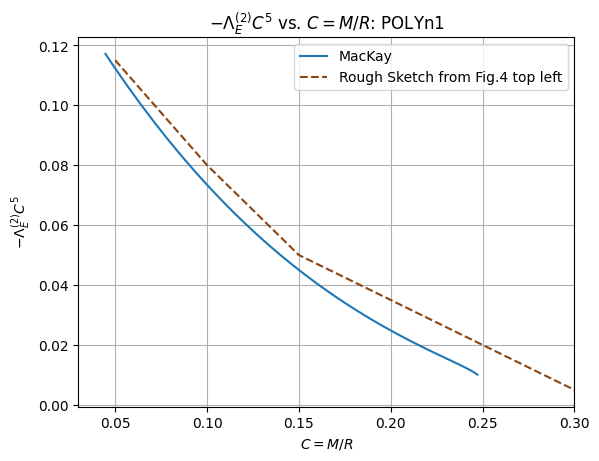

In [9]:
#-\tilde{\lambda}^{(2)}_E C^5 vs. C=M/R

f1 = plt.figure()

plt.plot(M_vals/R_vals, (5/np.pi)**(1/2)*k2_vals/2, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([0.115, 0.08, 0.05, 0.035, 0.005]), 
         label=r"Rough Sketch from Fig.4 top left", ls="--", color='saddlebrown')

plt.ylabel("$-\Lambda^{(2)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.xlim([0.03, 0.3])
plt.title("$-\Lambda^{(2)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

#f1.savefig("lam2c5_vs_c_POLYn1.png", bbox_inches='tight', dpi=300)


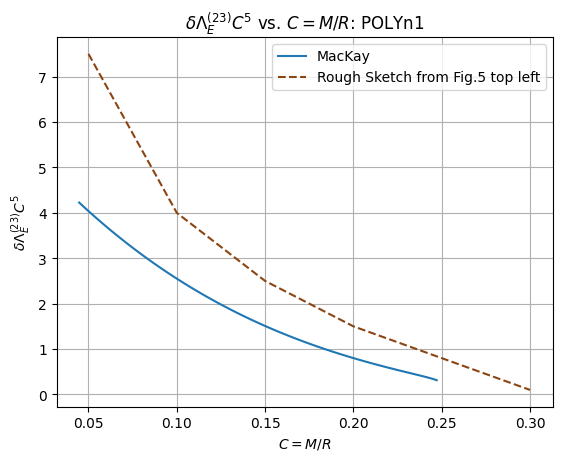

In [7]:
#\delta\tilde{\lambda}^{(23)}_E C^5 vs. C=M/R

def deltlam(k2_v, p32_v):
    k2 = k2_v
    p32 = p32_v
    return (1792/(3*(5*pi)**(1/2)))*p32*k2

dl23 = deltlam(k2_vals, P_vals)

f2 = plt.figure()

plt.plot(M_vals/R_vals, dl23, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.5, 4, 2.5, 1.5, 0.1]), 
         label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

plt.ylabel("$\delta\Lambda^{(23)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
#plt.xlim([0.05, 0.3])
#plt.ylim([-1, 14])
plt.title("$\delta\Lambda^{(23)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

#f2.savefig("dl23c5_vs_c_POLYn1.png", bbox_inches='tight', dpi=300)


If we introduce a factor of $\chi$ to the blue curve, and use $\chi\sim0.05$ as used in the literature, the blue curve would be even more suppressed in magnitude, risking the current close proximity between the two curves. On the contrary, the blue curve is off by some factor (~3/2) from the literature. However, as it currently reads, the computations and the literature curve are within the same order of magnitude.

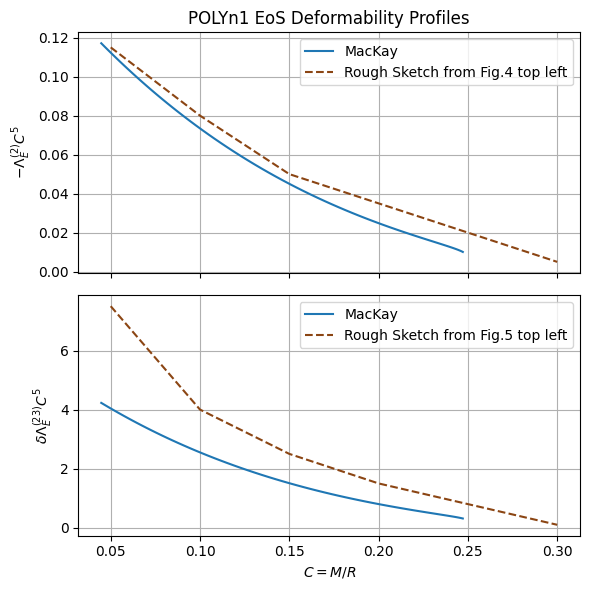

In [9]:
fig, axes = plt.subplots(figsize=(6, 6), nrows=2, sharex=True)

axes[0].set_title(r"POLYn1 EoS Deformability Profiles")
axes[0].plot(M_vals/R_vals, (5/np.pi)**(1/2)*k2_vals/2, label='MacKay')    
axes[0].plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([0.115, 0.08, 0.05, 0.035, 0.005]), 
         label=r"Rough Sketch from Fig.4 top left", ls="--", color='saddlebrown')
axes[0].set_ylabel("$-\Lambda^{(2)}_E C^5$")
axes[0].legend()
axes[0].grid()

axes[1].plot(M_vals/R_vals, dl23, label='MacKay')    
axes[1].plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.5, 4, 2.5, 1.5, 0.1]), 
         label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

axes[1].set_ylabel("$\delta\Lambda^{(23)}_E C^5$")
axes[1].set_xlabel(r"$C=M/R$")
axes[1].legend()
axes[1].grid()

fig.tight_layout()
plt.show()

#fig.savefig("NS_POLYn1_def_profs.png", bbox_inches='tight', dpi=300)

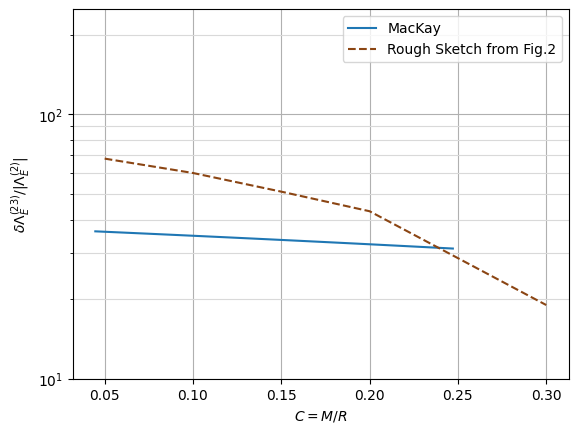

In [16]:
f=plt.figure()

plt.plot(M_vals/R_vals, dl23/((5/np.pi)**(1/2)*k2_vals/2), label=r"MacKay")
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([68, 60, 51, 43,  19]), 
         label=r"Rough Sketch from Fig.2", ls="--", color='saddlebrown')
plt.ylabel("$\delta\Lambda^{(23)}_E/|\Lambda^{(2)}_E|$")
plt.ylim([10, 250])
plt.yscale('log')
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend()
plt.xlabel("$C=M/R$");

#f.savefig("rec_v3.png", bbox_inches='tight', dpi=300)


There is reason to suggest, reading the paragraph below Pani II Eq. (42) that $\delta\tilde{\lambda}^{(23)}_E\sim p_{23}k^*_3$. The Love number $k_{23}$ is analyzed in the novel Wolfram Mathematica Love solver supplement to the thesis. However, the coupling's Newtonian limit is $\sim C^{-4}$, which is off from the literature's claim that $\delta\tilde{\lambda}^{(23)}_E\sim C^{-5}$. In addition, $k^*_3$ is negative. We demonstrate here that this particular coupling could not replicate the literature's curve profile.

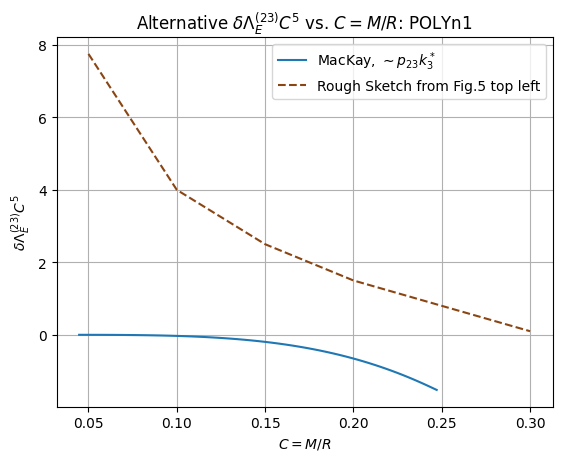

In [7]:
def p23(M_v, R_v, y23):
    c=M_v/R_v
    return (896*(7/5)**(1/2)* (2*c*(210*(-2 + y23) + 8*c**6*(2 + y23) + 8*c**7*(4 + y23) 
                                    +6*c**5*(8 + 5*y23) - 30*c*(-59 + 38*y23) + 4*c**4*(29 + 38*y23) 
                                    -5*c**3*(-80 + 279*y23) + 5*c**2*(-418 + 419*y23)) 
                               +15*(1 - 2*c)**2*(14*(-2 + y23) - 34*c*(-1 + y23) +19*c**2*y23)*np.log(1 - 2*c)))/(
        3*c*(2*c*(6 + c**2*(26 - 22*y23) - 3*y23 + 4*c**4*(1 + y23) + 3*c*(-8 + 5*y23) + c**3*(-4 + 6*y23))
             +3*(1 - 2*c)**2*(2 + 2*c*(-1 + y23) - y23)*np.log(1 - 2*c)))

def dlam23(p, k):
    return (224/16)*p*k

plt.plot(M_vals/R_vals, dlam23(p23(M_vals, R_vals, Y2_vals), ks3_vals), label=r'MacKay, $\sim p_{23}k^*_3$')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.75, 4, 2.5, 1.5, 0.1]), 
         label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

plt.ylabel("$\delta\Lambda^{(23)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
#plt.xlim([0.05, 0.3])
#plt.ylim([-1, 14])
plt.title("Alternative $\delta\Lambda^{(23)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

The argument for $y_{23}$ in the polynomial $p_{23}$ is the $y_2$ value (solved by the same ODE but sourceless). Using this as a proxy to $y_{23}$ is inspired by the discussion regading $y^*_{32}$ and $y^*_3$, where the source term contributed hardly any to the computation of $y^*_{32}$ -- as evidenced by the difference $\Delta y^*=|y^*_{32}-y^*_3|$. We make a critical assumption that this holds true for the difference in $\Delta y=|y_{23}-y_2|$. 

## Computing Spin-Corrected Tidal Deformability

We make preliminary computations to the up-to-$\mathcal{O}(\chi)$ expression that contains both tidal field $M/r_0$ and orbital $\sqrt{M_\text{total}/r_0}$ factors. For a weak-field, large separation limit, we use $r_0\sim 5R$ and $M_\text{total}\sim 2M$ used in https://arxiv.org/abs/1509.02171 .

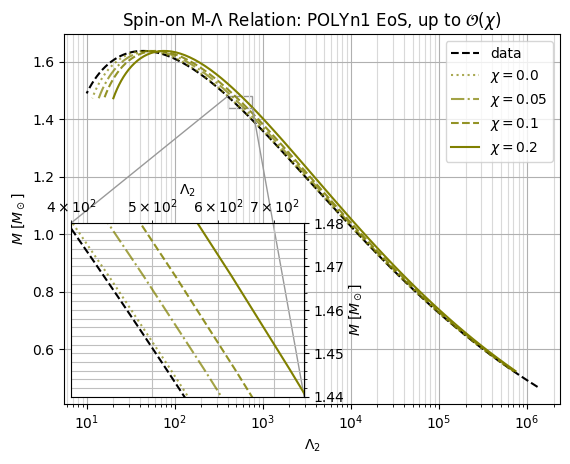

In [13]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def totx1(x, k2, M, R, p32):
    C=M/R
    return (2/3)*(1 + x*(10752/((35)**(1/2)))*p32*(M/(5*R))*(2*M/(5*R))**(1/2))* k2 * C**(-5)

def totx2(x, k2, ks3, ps32, M, R):
    C = M/R
    return (2/3)*(1 - x**2*(3211264/2615)*(ps32*C)**2*(k2/ks3)) * k2 * C**(-5)
    

chi=[0.00, 0.05, 0.10, 0.20]
ls_rack=[':','-.','--','-']
alphs=[0.675, 0.725, 0.85, 1]

fig, ax = plt.subplots()

ax.semilogx(dataL_POLYn1, dataM_POLYn1,
            color='black', ls='--', label='data')

for x, lsd, a in zip(chi, ls_rack, alphs):
    lamx1 = totx1(x, k2_vals, M_vals, R_vals, P_vals)
    ax.semilogx(lamx1, M_vals,
                color='olive', ls=lsd, alpha=a,
                label=rf"$\chi={x}$")

ax.set_xlabel(r"$\Lambda_2$")
ax.set_ylabel(r"$M$ [$M_\odot$]")
ax.set_title("Spin-on M-Λ Relation: POLYn1 EoS, up to $\mathcal{O}(\chi)$")
ax.grid()
ax.grid(which="minor", color="0.85")
ax.legend()

# Create inset
axins = inset_axes(ax, width="47%", height="47%", loc='lower left')

# Plot the same curves
axins.semilogx(dataL_POLYn1, dataM_POLYn1,
               color='black', ls='--')

for x, lsd, a in zip(chi, ls_rack, alphs):
    lamx1 = totx1(x, k2_vals, M_vals, R_vals, P_vals)
    axins.semilogx(lamx1, M_vals,
                   color='olive', ls=lsd, alpha=a)

# Set zoom region
axins.set_xlim(400, 760)
axins.set_ylim(1.44, 1.48)
#axins.set_xticks([])
#axins.set_yticks([])
axins.xaxis.tick_top()
axins.yaxis.tick_right()
axins.tick_params(
    labeltop=True,
    labelbottom=False,
    labelright=True,
    labelleft=False
)
axins.grid(which='major', color='0.75')
axins.grid(which='minor', color='0.75')
axins.minorticks_on()
axins.xaxis.set_label_position('top')
axins.yaxis.set_label_position('right')
axins.set_xlabel(r"$\Lambda_2$", labelpad=2)
axins.set_ylabel(r"$M$ [$M_\odot$]", labelpad=2)

# Connect inset to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.6")

plt.show()
#fig.savefig("chi1_MLcurve_POLYn1.png", bbox_inches='tight', dpi=300)

Consider the NS mass $M=1.46~M_\odot$, close to the canonical value $M=1.4~M_\odot$. We extract the particular values of tidal deformability for each value of $\chi$.

In [12]:
print(M_vals[36])
print()
for x in chi:
    print(totx1(x, k2_vals, M_vals, R_vals, P_vals)[36])

1.4677986684598257

443.79186343467404
488.4261191538208
533.0603748729675
622.328886311261


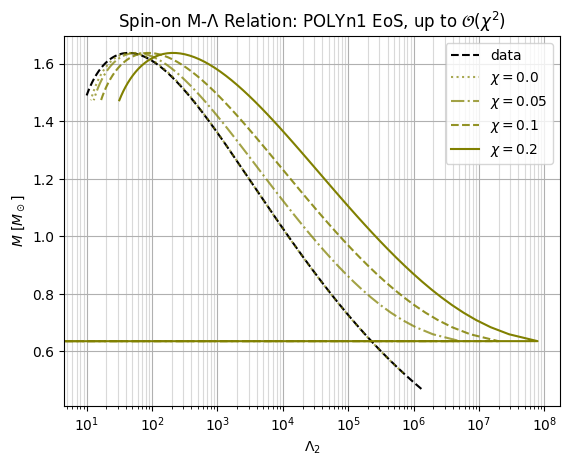

In [13]:
chi=[0.00, 0.05, 0.10, 0.20]
ls_rack=[':','-.','--','-']
alphs=[0.675, 0.725, 0.85, 1]

f = plt.figure()

plt.semilogx(dataL_POLYn1, dataM_POLYn1, color='black', ls = '--', label='data')    

for x, lsd, a in zip(chi, ls_rack, alphs):
    lamx2 = totx2(x, k2_vals, ks3_vals, P_vals, M_vals, R_vals)
    plt.semilogx(lamx2, M_vals, color='olive', ls=lsd, alpha=a, label=rf"$\chi={x}$")
   
plt.xlabel("$\Lambda_2$")
plt.ylabel("$M$ [$M_\odot$]")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.title("Spin-on M-Λ Relation: POLYn1 EoS, up to $\mathcal{O}(\chi^2)$")
plt.legend();

#f.savefig("chi2_MLcurve_POLYn1.png", bbox_inches='tight', dpi=300)

Because $k^*_3$ is small, its placement as a denominator term makes the overall contribution large -- unphysically so. There is a region in the low density branch where $k^*_3$ is positive (it is mainly negative), which causes the sharp cutoff above $M=0.6~M_\odot$. This suddenly shifts the low density values into an unphysical negative range in $\Lambda$, giving it further reason why this calculation is particuarly irrelevant.

In [13]:
print(ks3_vals)

[ 6.29067278e-06  5.05529934e-06  3.65673105e-06  2.08276204e-06
  3.21184886e-07 -1.64054227e-06 -3.81511505e-06 -6.21545852e-06
 -8.85449994e-06 -1.17451305e-05 -1.49001277e-05 -1.83320339e-05
 -2.20525477e-05 -2.60736855e-05 -3.04062121e-05 -3.50602184e-05
 -4.00448160e-05 -4.53681341e-05 -5.10367952e-05 -5.70562397e-05
 -6.34301331e-05 -7.01605931e-05 -7.72477928e-05 -8.46899413e-05
 -9.24831448e-05 -1.00621365e-04 -1.09096311e-04 -1.17897391e-04
 -1.27011744e-04 -1.36424186e-04 -1.46117277e-04 -1.56071402e-04
 -1.66264857e-04 -1.76673933e-04 -1.87273148e-04 -1.98035383e-04
 -2.08932091e-04 -2.19933427e-04 -2.31008956e-04 -2.42126970e-04
 -2.53255717e-04 -2.64362765e-04 -2.75417817e-04 -2.86387475e-04
 -2.97241511e-04 -3.07949451e-04 -3.18483194e-04 -3.28813561e-04
 -3.38915923e-04 -3.48764093e-04 -3.58335427e-04 -3.67608623e-04
 -3.76564206e-04 -3.85184073e-04 -3.93454046e-04 -4.01358706e-04
 -4.08886433e-04 -4.16026973e-04 -4.22771914e-04 -4.29113720e-04
 -4.35047092e-04 -4.40567